In [1]:
import os
import sys
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import itertools
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
seed = 1234
rng = np.random.default_rng(seed)
np.random.seed(1234)

In [2]:
plt.rcParams.update({
    'axes.labelsize': 18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 16,
    'axes.titlesize': 18,
    'font.size': 18,
    'lines.linewidth': 1.5,
    'text.usetex': False,
    'mathtext.fontset': 'stix',
    'font.family': 'STIXGeneral'
})

In [3]:
def analyN(r1, r2, a1, a12, a21, a2):
    denom = a1 - a21*a12/a2
    if denom == 0 or a2 == 0:
        N1 = np.nan
        N2 = np.nan
    else:
        N1 = (r1 - 1 - (a12/a2)*(r2 - 1)) / denom
        N2 = (r2 - 1 - (a21/a1)*(r1 - 1)) / (a2 - a21*a12/a1)
    return N1, N2

In [4]:
def updateN(r_arg, Nself, N1, a_intra, a1, rng_state):
    mean_new = (r_arg * Nself) / (1 + a_intra * Nself + a1 * N1)
    if mean_new <= 0:
        return 0
    return rng_state.poisson(mean_new)

In [5]:
def run_single_sim(l1, l2, a11, a12, a21, a22, N0_1, N0_2, max_time, rng_state):
    N1 = N0_1
    N2 = N0_2
    t = 0
    N1_ts = [N1]
    N2_ts = [N2]
    while t < max_time:
        t += 1
        newN1 = updateN(l1, N1, N2, a11, a12, rng_state)
        newN2 = updateN(l2, N2, N1, a22, a21, rng_state)
        N1, N2 = newN1, newN2
        N1_ts.append(N1)
        N2_ts.append(N2)
        if N1 == 0 or N2 == 0:
            break
    return np.array(N1_ts), np.array(N2_ts), t

In [6]:
def run_iterations(l1, l2, a11, a12, a21, a22, iterations, max_time, N0_1, N0_2, base_seed):
    persistence = np.full((iterations, 2), np.nan)
    mt = np.full((iterations, 2), np.nan)
    for j in range(iterations):
        seed_j = base_seed + j
        rng_j = np.random.default_rng(seed_j)
        N1_ts, N2_ts, steps = run_single_sim(l1, l2, a11, a12, a21, a22, N0_1, N0_2, max_time, rng_j)
        persistence[j, 0] = steps if N1_ts[-1] == 0 else np.nan
        persistence[j, 1] = steps if N2_ts[-1] == 0 else np.nan
        mt[j, 0] = N1_ts.mean()
        mt[j, 1] = N2_ts.mean()
    coexist = np.min(persistence, axis=1)
    meanN1 = np.mean(mt[:, 0])
    medN1 = np.median(mt[:, 0])
    meanN2 = np.mean(mt[:, 1])
    medN2 = np.median(mt[:, 1])
    sdN1 = np.std(mt[:, 0])
    sdN2 = np.std(mt[:, 1])
    MTC = np.mean(coexist[~np.isnan(coexist)])
    medTC = np.median(coexist[~np.isnan(coexist)])
    MTP1 = np.mean(persistence[~np.isnan(persistence[:,0]), 0])
    medTP1 = np.median(persistence[~np.isnan(persistence[:,0]), 0])
    MTP2 = np.mean(persistence[~np.isnan(persistence[:,1]), 1])
    medTP2 = np.median(persistence[~np.isnan(persistence[:,1]), 1])
    Ext1 = np.sum(~np.isnan(persistence[:,0])) / iterations
    Ext2 = np.sum(~np.isnan(persistence[:,1])) / iterations
    return (meanN1, medN1, meanN2, medN2, sdN1, sdN2, MTC, medTC, MTP1, medTP1, MTP2, medTP2, Ext1, Ext2)

In [7]:
def stochastic_grid(rare_df, iterations, max_time, n_jobs, base_seed):
    results = Parallel(n_jobs=n_jobs)(
        delayed(run_iterations)(
            row.l1, row.l2, row.a11, row.a12, row.a21, row.a22,
            iterations, max_time, 5, 5, base_seed + idx
        ) for idx, row in rare_df.iterrows()
    )
    res_df = rare_df.copy()
    cols = ['meanN1','medN1','meanN2','medN2','sdN1','sdN2','MTC','medTC','MTP1','medTP1','MTP2','medTP2','Ext1','Ext2']
    for i, col in enumerate(cols):
        res_df[col] = [r[i] for r in results]
    return res_df

In [8]:
def deterministic_grid(l1s, l2s, a11s, a12s, a21s, a22s):
    combos = list(itertools.product(l1s, l2s, a11s, a12s, a21s, a22s))
    N1_list, N2_list = [], []
    for r1, r2, a11, a12, a21, a22 in combos:
        n1, n2 = analyN(r1, r2, a11, a12, a21, a22)
        N1_list.append(n1)
        N2_list.append(n2)
    df = pd.DataFrame(combos, columns=['l1','l2','a11','a12','a21','a22'])
    df['N1'] = N1_list
    df['N2'] = N2_list
    df['coexist'] = ((df['N1'] > 0) & (df['N2'] > 0)).astype(int)
    return df

In [9]:
def compute_stabilization(df):
    df['S1'] = df['l2'] / (1 + (df['a12']/df['a22']) * (df['l2'] - 1))
    df['S2'] = df['l1'] / (1 + (df['a21']/df['a11']) * (df['l1'] - 1))
    df['E1'] = df['l1'] / df['l2']
    totalN = df['N1'] + df['N2']
    df['freq1'] = df['N1'] / totalN.replace(0, np.nan)
    # covariance between abundance and stabilization
    cov_list = []
    for _, row in df.iterrows():
        cov_val = np.cov([row.N1, row.N2], [row.S1, row.S2])[0,1] if not np.isnan(row.freq1) else np.nan
        cov_list.append(cov_val)
    df['v'] = cov_list
    return df

In [10]:
def filter_rare(df):
    rare_df = df[df['freq1'] <= 0.25].copy()
    return rare_df

In [11]:
def compute_S1_metric(r2, a12, a22):
    return r2 / (1 + (a12 / a22) * (r2 - 1))

In [12]:
def classify_row(r1, r2, a11, a12, a21, a22):
    if r2 == 1 or r1 == 1:
        return 'borderline'
    thresh12 = a22 * (r1 - 1) / (r2 - 1)
    thresh21 = a11 * (r2 - 1) / (r1 - 1)
    if np.isclose(a12, thresh12) and np.isclose(a21, thresh21):
        return 'borderline'
    if a12 > thresh12 and a21 > thresh21:
        return 'saddle'
    if a12 < thresh12 and a21 < thresh21:
        return 'stable_coexistence'
    if a12 < thresh12 and a21 > thresh21:
        return 'exclusion_N1'
    return 'exclusion_N2'

In [13]:
def generate_all_fig2_candidates(params_df):
    classifications = params_df.apply(lambda row: classify_row(row['r1'], row['r2'], row['a11'], row['a12'], row['a21'], row['a22']), axis=1)
    params_df = params_df.assign(class_=classifications)
    mask_valid = (params_df['class_'] != 'saddle') & (params_df['class_'] != 'borderline')
    df_valid = params_df[mask_valid].copy()
    S1_vals = compute_S1_metric(df_valid['r2'].values, df_valid['a12'].values, df_valid['a22'].values)
    df_valid = df_valid.assign(S1=S1_vals)
    mask_pop = (df_valid['N1'] <= 25) & (df_valid['N2'] <= 25)
    df_valid = df_valid[mask_pop]
    os.makedirs("fig2_plots", exist_ok=True)
    for idx, row in df_valid.iterrows():
        rng = np.random.default_rng(seed=1234)
        N1_ts, N2_ts, _ = run_single_sim(row.r1, row.r2, row.a11, row.a12, row.a21, row.a22, 5, 5, 50, rng)
        min_len = min(len(N1_ts), len(N2_ts))
        t_vals = np.arange(min_len)
        fig, ax = plt.subplots(figsize=(5,4))
        ax.plot(t_vals, N1_ts[:min_len], 'k-', linewidth=1, label='Rare species')
        ax.plot(t_vals, N2_ts[:min_len], 'k--', linewidth=1, label='Dominant species')
        ax.set_xlabel("Year of simulation")
        ax.set_ylabel("Simulated population size")
        ax.legend(frameon=False)
        ax.set_xlim(0, 50)
        plt.tight_layout()
        fname = f"fig2_plots/r1_{row.r1:.3g}_r2_{row.r2:.3g}_a11_{row.a11:.3g}_a12_{row.a12:.3g}_a21_{row.a21:.3g}_a22_{row.a22:.3g}_S1_{row.S1:.3g}.png"
        plt.savefig(fname, dpi=150)
        plt.close()
    print(f"Saved {len(df_valid)} candidate figures in 'fig2_plots' folder.")

In [14]:
def generate_specific_figure2():
    param_w = {'r1': 18, 'r2': 15, 'a11': 1.0, 'a12': 0.5, 'a21': 0.5, 'a22': 0.5}
    param_s = {'r1': 16, 'r2': 17, 'a11': 2.5, 'a12': 0.1, 'a21': 0.9, 'a22': 0.7}
    rng_w = np.random.default_rng(seed=1234)
    rng_s = np.random.default_rng(seed=1235)
    N1_w, N2_w, _ = run_single_sim(param_w['r1'], param_w['r2'], param_w['a11'], param_w['a12'], param_w['a21'], param_w['a22'], 5, 5, 50, rng_w)
    N1_s, N2_s, _ = run_single_sim(param_s['r1'], param_s['r2'], param_s['a11'], param_s['a12'], param_s['a21'], param_s['a22'], 5, 5, 50, rng_s)
    min_len_w = min(len(N1_w), len(N2_w))
    min_len_s = min(len(N1_s), len(N2_s))
    t_w = np.arange(min_len_w)
    t_s = np.arange(min_len_s)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8), sharex=True)
    ax1.plot(t_w, N1_w[:min_len_w], 'k-', linewidth=1, label='Rare species')
    ax1.plot(t_w, N2_w[:min_len_w], 'k--', linewidth=1, label='Dominant species')
    ax1.set_xlim(0, 50)
    ax1.set_ylim(0, 40)
    ax1.legend(frameon=False)
    ax1.text(0.02, 0.95, '(a)', transform=ax1.transAxes, va='top', ha='left')
    ax2.plot(t_s, N1_s[:min_len_s], 'k-', linewidth=1, label=None)
    ax2.plot(t_s, N2_s[:min_len_s], 'k--', linewidth=1, label=None)
    ax2.set_xlim(0, 50)
    ax2.set_ylim(0, 40)
    ax2.legend(frameon=False)
    ax2.text(0.02, 0.95, '(b)', transform=ax2.transAxes, va='top', ha='left')
    fig.subplots_adjust(left=0.12, right=0.95, bottom=0.1, top=0.95, hspace=0.3)
    fig.text(0.5, 0.02, 'Year of simulation', ha='center', va='center', fontsize=20)
    fig.text(0.02, 0.5, 'Simulated population size', ha='center', va='center', rotation='vertical', fontsize=20)
    plt.savefig('img/fig2_yenni.pdf', dpi=300, bbox_inches='tight', pad_inches=0.1)
    plt.savefig('img/fig2_yenni.png', dpi=300, bbox_inches='tight', pad_inches=0.1)
    plt.show()

In [15]:
def deterministic_grid_paper():
    r1_vals = list(range(15, 21))
    r2_vals = list(range(11, 21))
    a11_vals = np.arange(0.7, 3.1, 0.1).round(1)
    a22_vals = np.arange(0.1, 1.1, 0.1).round(1)
    a12_vals = a22_vals.copy()
    a21_vals = a22_vals.copy()
    combos = list(itertools.product(r1_vals, r2_vals, a11_vals, a12_vals, a21_vals, a22_vals))
    N1_list, N2_list = [], []
    for r1, r2, a11, a12, a21, a22 in combos:
        n1, n2 = analyN(r1, r2, a11, a12, a21, a22)
        N1_list.append(n1)
        N2_list.append(n2)
    df = pd.DataFrame(combos, columns=['r1', 'r2', 'a11', 'a12', 'a21', 'a22'])
    df['N1_det'] = N1_list
    df['N2_det'] = N2_list
    mask = (df['N1_det'] > 0) & (df['N2_det'] > 0)
    df = df[mask].copy()
    total = df['N1_det'] + df['N2_det']
    df['Rare'] = df['N1_det'] / total
    df = df[df['Rare'] <= 0.25].copy()
    df['S1'] = df['r2'] / (1 + (df['a12'] / df['a22']) * (df['r2'] - 1))
    df['S2'] = df['r1'] / (1 + (df['a21'] / df['a11']) * (df['r1'] - 1))
    df['E1'] = df['r1'] / df['r2']
    return df

In [16]:
def compute_medTC(params, iterations, max_steps, init1, init2, base_seed):
    r1, r2, a11, a12, a21, a22 = params
    rng = np.random.default_rng(base_seed)
    times = np.empty(iterations, dtype=np.float64)
    for j in range(iterations):
        N1, N2 = init1, init2
        steps = 0
        while steps < max_steps and N1 > 0 and N2 > 0:
            mean1 = r1 * N1 / (1 + a11 * N1 + a12 * N2)
            N1_new = rng.poisson(mean1) if mean1 > 0 else 0
            mean2 = r2 * N2 / (1 + a22 * N2 + a21 * N1)
            N2_new = rng.poisson(mean2) if mean2 > 0 else 0
            N1, N2 = N1_new, N2_new
            steps += 1
        times[j] = steps
    return np.median(times)

In [17]:
def run_stochastic_fig3(df_rare, iterations, max_steps, init1, init2, seed_base):
    param_list = [(row['r1'], row['r2'], row['a11'], row['a12'], row['a21'], row['a22']) for _, row in df_rare.iterrows()]
    medTCs = Parallel(n_jobs=-1, verbose=0)(
        delayed(compute_medTC)(params, iterations, max_steps, init1, init2, seed_base + i)
        for i, params in enumerate(param_list)
    )
    return medTCs

In [18]:
def make_fig3(df):
    df = df[(df['Rare'] <= 0.25) & (df['r1'] > 14)].copy()
    bins = [(1, 2), (2, 3), (3, 4), (4, np.inf)]
    fig, axes = plt.subplots(2, 4, figsize=(14, 8), sharex=True, sharey='row')
    for row_idx, species in enumerate([1, 2]):
        col_name = f'S{species}'
        for col_idx, (low, high) in enumerate(bins):
            ax = axes[row_idx, col_idx]
            mask = (df[col_name] >= low) & (df[col_name] < high)
            data = df.loc[mask, 'medTC'].dropna()
            if len(data) == 0:
                ax.set_visible(False)
                continue
            log_data = np.log(data)
            ax.hist(log_data, bins=30, density=True, color='grey', edgecolor='darkgrey', alpha=0.7)
            kde = gaussian_kde(log_data)
            x_range = np.linspace(log_data.min(), log_data.max(), 200)
            ax.plot(x_range, kde(x_range), 'k-', linewidth=1)
            ax.axvline(np.median(log_data), color='black', linewidth=1)
            if col_idx == 0:
                ax.set_ylabel('Density')
            if row_idx == 1 and col_idx == 1:
                ax.set_xlabel('ln(median coexistence time)')
    plt.tight_layout()
    plt.savefig('img/figure3_yenni.png', dpi=300)
    plt.show()

In [19]:
def generate_fig3():
    df_rare = deterministic_grid_paper()
    medTCs = run_stochastic_fig3(df_rare, 2000, 50000, 5, 5, seed)
    df_rare['medTC'] = medTCs
    df_rare.to_csv('annplant_2spp_fig3.csv', index=False)
    make_fig3(df_rare)

In [20]:
def execute_pipeline(run_full=False):
    params_df = pd.read_csv("csv/parameters_fig2.csv")
    generate_specific_figure2()
    if run_full:
        generate_all_fig2_candidates(params_df)
        generate_fig3()

In [21]:
def main():
    execute_pipeline(run_full=False)

/tmp/ipykernel_590600/627060277.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(frameon=False)


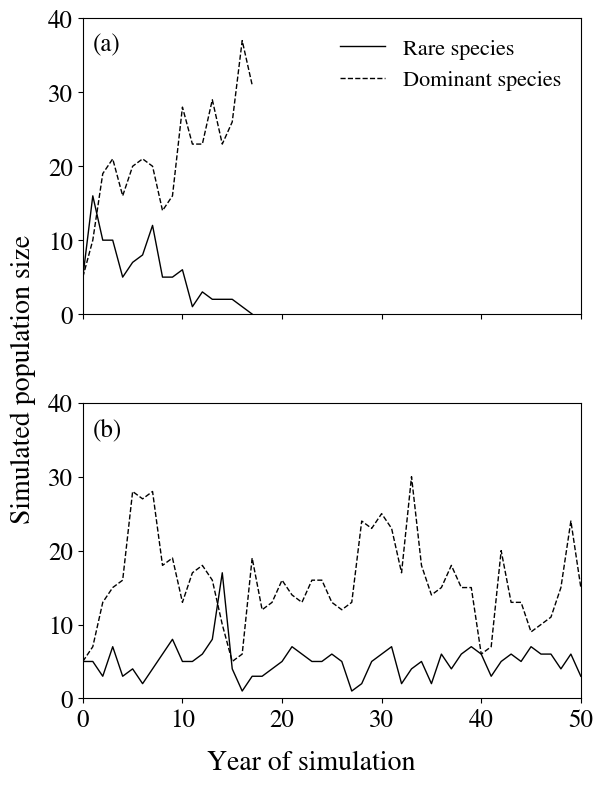

In [22]:
if __name__ == '__main__':
    main()